In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Netflix user data from the CSV file
data_path = 'data/netflix_users.csv'
df = pd.read_csv(data_path)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/netflix_users.csv'

In [ ]:
print("Dataset Information:")
df.info()
print("\n" + "="*50 + "\n")



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB




In [ ]:
print("Missing Values in Each Column:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

Missing Values in Each Column:
User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64




In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print("\n" + "="*50 + "\n")

Number of duplicate rows: 0




In [ ]:
# Check for unique values in categorical columns to spot inconsistencies
unique_counts = df.nunique()

print("\nCount of Unique Values per Column:")
print(unique_counts)


Count of Unique Values per Column:
User_ID              25000
Name                   100
Age                     68
Country                 10
Subscription_Type        3
Watch_Time_Hours     22087
Favorite_Genre           7
Last_Login             366
dtype: int64


In [ ]:
print(df['Name'].unique())

['James Martinez' 'John Miller' 'Emma Davis' 'Emma Miller' 'Jane Smith'
 'David Johnson' 'John Hernandez' 'Katie Hernandez' 'James Williams'
 'Alex Davis' 'Jane Miller' 'Jane Martinez' 'Alex Martinez' 'Alex Smith'
 'Michael Jones' 'Chris Miller' 'Chris Davis' 'Emma Williams'
 'Alex Johnson' 'John Jones' 'Michael Williams' 'Sarah Davis' 'John Smith'
 'Alex Brown' 'Chris Johnson' 'James Jones' 'Michael Johnson'
 'Sarah Smith' 'Chris Jones' 'John Williams' 'Jane Brown' 'David Davis'
 'Emma Hernandez' 'Sarah Williams' 'David Martinez' 'Emma Smith'
 'Sarah Hernandez' 'David Brown' 'Chris Garcia' 'John Johnson'
 'Sarah Garcia' 'Michael Brown' 'David Hernandez' 'Sarah Jones'
 'Alex Jones' 'Chris Martinez' 'Jane Garcia' 'Michael Martinez'
 'Chris Smith' 'Alex Hernandez' 'James Hernandez' 'Katie Martinez'
 'David Smith' 'James Davis' 'David Garcia' 'Alex Williams' 'Emma Brown'
 'Michael Davis' 'Emma Garcia' 'John Brown' 'Jane Davis' 'Michael Smith'
 'Emma Johnson' 'Katie Williams' 'Katie Jones'

In [ ]:
# Check for duplicate User_IDs
duplicate_user_ids = df[df.duplicated('User_ID', keep=False)]

if not duplicate_user_ids.empty:
    print("\nDuplicate User_IDs Found:")
    print(duplicate_user_ids)
else:
    print("\nNo duplicate User_IDs found. All users are unique.")

# A quicker way to just get the count
num_duplicates = df.duplicated('User_ID').sum()
print(f"\nTotal number of duplicate User_ID records: {num_duplicates}")


No duplicate User_IDs found. All users are unique.

Total number of duplicate User_ID records: 0


In [ ]:
# Get the list of unique values for key categorical columns
print("\nUnique values in 'Country':")
print(df['Country'].unique())

print("\nUnique values in 'Subscription_Type':")
print(df['Subscription_Type'].unique())

print("\nUnique values in 'Favorite_Genre':")
print(df['Favorite_Genre'].unique())

print("\nUnique values in 'Favorite_Genre':")
print(df['Favorite_Genre'].unique())



Unique values in 'Country':
['France' 'USA' 'UK' 'Canada' 'Mexico' 'Japan' 'Australia' 'Germany'
 'Brazil' 'India']

Unique values in 'Subscription_Type':
['Premium' 'Basic' 'Standard']

Unique values in 'Favorite_Genre':
['Drama' 'Sci-Fi' 'Comedy' 'Documentary' 'Romance' 'Action' 'Horror']

Unique values in 'Favorite_Genre':
['Drama' 'Sci-Fi' 'Comedy' 'Documentary' 'Romance' 'Action' 'Horror']


Favorite_Genre
Horror         3654
Documentary    3636
Action         3589
Romance        3572
Comedy         3561
Drama          3533
Sci-Fi         3455
Name: count, dtype: int64

In [ ]:
df['Country'].value_counts()
# The output shows that the dataset has a good representation of users from different countries, with the highest number of users from the United States, followed by India and Brazil. This diversity can help in building a more generalized model for Netflix user classification.


Country
UK           2592
Germany      2547
India        2505
USA          2503
Brazil       2503
Mexico       2493
Canada       2490
France       2473
Japan        2457
Australia    2437
Name: count, dtype: int64

In [ ]:
df['Subscription_Type'].value_counts()
# The output indicates that the majority of users have a 'Basic' subscription, followed by 'Standard' and 'Premium'. This distribution can provide insights into user preferences and may influence the classification model's performance based on subscription types.


Subscription_Type
Premium     8402
Basic       8356
Standard    8242
Name: count, dtype: int64

In [ ]:
df['Favorite_Genre'].value_counts()
# The output reveals that 'Horror' is the most popular genre among Netflix users in the dataset, followed by 'Documentary' and 'Action'. This information can be useful for understanding user preferences and may help in feature engineering for the classification model.

Favorite_Genre
Horror         3654
Documentary    3636
Action         3589
Romance        3572
Comedy         3561
Drama          3533
Sci-Fi         3455
Name: count, dtype: int64

In [ ]:
# Check the range of 'Last_Login' to see if there are any outliers or incorrect dates
print("\nRange of 'Last_Login':")
print(f"Minimum Last_Login: {df['Last_Login'].min()}")
print(f"Maximum Last_Login: {df['Last_Login'].max()}")


Range of 'Last_Login':
Minimum Last_Login: 2024-03-08 00:00:00
Maximum Last_Login: 2025-03-08 00:00:00


In [ ]:
df['Last_Login'].max()

Timestamp('2025-03-08 00:00:00')

In [ ]:
df.head()


,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


Churn
1    22919
0     2081
Name: count, dtype: int64


C:\Users\Kushal\AppData\Local\Temp\ipykernel_11236\2162458895.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='coolwarm')


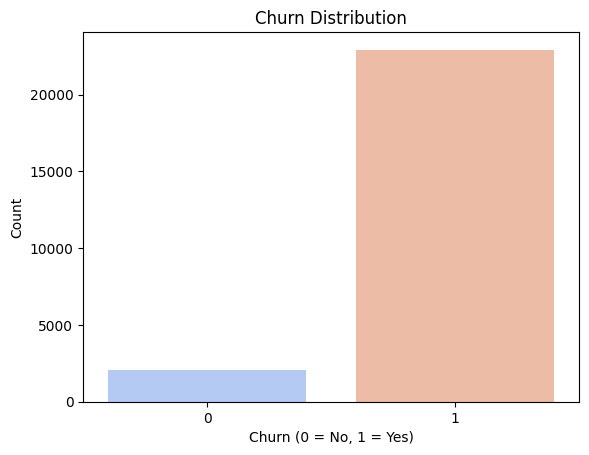

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df['Churn'].value_counts())
sns.countplot(x='Churn', data=df, palette='coolwarm')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [ ]:
df['Watch_Time_Hours'] = pd.to_numeric(df['Watch_Time_Hours'], errors='coerce')
df['Watch_Time_Hours'].fillna(df['Watch_Time_Hours'].median(), inplace=True)

In [ ]:
df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Churn,Days_Since_Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,1,301
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05,1,32
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,1,44
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,1,349
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14,1,54


In [37]:
# Ensure required variables are defined
if 'df' not in globals():
	raise NameError("The variable 'df' is not defined. Please run the cell where you load the DataFrame.")
if 'model_columns' not in globals():
	raise NameError("The variable 'model_columns' is not defined. Please run the cell where you define model_columns.")

# Select columns for modeling (excluding columns like 'Name', 'User_ID', etc. if not needed)
df_for_model = df[model_columns].copy()

print("Columns selected for modeling:")
print(df_for_model.columns.tolist())
print("-" * 30)

# Step 2: Identify the categorical columns from our new DataFrame
# categorical_cols is already defined

# Step 3: Apply pd.get_dummies() ONLY to the DataFrame we prepared
df_encoded = pd.get_dummies(df_for_model, columns=categorical_cols, drop_first=True)

# Step 4: Print the results to verify
print("Shape of original df:", df.shape)
print("Shape of model-ready df_encoded:", df_encoded.shape)
print("\nFirst 5 rows of the encoded DataFrame:")
print(df_encoded.head())

NameError: The variable 'df' is not defined. Please run the cell where you load the DataFrame.